# Amazon Watches Web Scraping & Product Analysis using Python

#### This project focuses on scraping Amazon watch product data using Python, cleaning the extracted data, and performing exploratory data analysis to identify top products, popular brands, pricing patterns, and rating trends.

In [ ]:
!pip install bs4

In [2]:
import pandas as pd
import time
import requests
from bs4 import BeautifulSoup


In [2]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
}

clean_Brand = []
description = []
star_rating = []
no_of_reviews = []
price = []
delivery_date = []

for i in range(40):
    url = f"https://www.amazon.in/s?i=watches&srs=207171480031&rh=n%3A207171480031&s=popularity-rank&fs=true&page={i}&ref=sr_pg_{i}"
    
    response = requests.get(url, headers=headers)
    print(f"Page {i}:", response.status_code)

    soup = BeautifulSoup(response.content, "html.parser")

    card = soup.find_all("div", class_="a-section a-spacing-base desktop-grid-content-view")
    # print(f"Products found on page {i}: {len(card)}")

    for item in card:
        brand = item.find("span", class_="a-size-base-plus a-color-base")
        desc = item.find("h2", class_="a-size-base-plus a-spacing-none a-color-base a-text-normal")
        rating = item.find("span", class_="a-size-small a-color-base")
        reviews = item.find("span", class_="a-size-mini puis-normal-weight-text s-underline-text")
        pr = item.find("span", class_="a-price-whole")
        delivery = item.find("span", class_="a-text-bold")

        clean_Brand.append(brand.text.strip() if brand else "Nan")
        description.append(desc.text.strip() if desc else "Nan")
        star_rating.append(rating.text.strip() if rating else "Nan")
        no_of_reviews.append(reviews.text.strip() if reviews else "Nan")
        price.append(pr.text.strip() if pr else "Nan")
        delivery_date.append(delivery.text.strip() if delivery else "Nan")

    time.sleep(2)

df = pd.DataFrame({
    "Brand": clean_Brand,
    "Description": description,
    "Star ratings": star_rating,
    "No. of reviews": no_of_reviews,
    "Price": price,
    "Delivery Date": delivery_date
})

df.info()

Page 0: 200
Page 1: 200
Page 2: 200
Page 3: 200
Page 4: 200
Page 5: 200
Page 6: 200
Page 7: 200
Page 8: 200
Page 9: 200
Page 10: 200
Page 11: 200
Page 12: 200
Page 13: 200
Page 14: 200
Page 15: 200
Page 16: 200
Page 17: 200
Page 18: 200
Page 19: 200
Page 20: 200
Page 21: 200
Page 22: 200
Page 23: 200
Page 24: 200
Page 25: 200
Page 26: 200
Page 27: 200
Page 28: 200
Page 29: 200
Page 30: 200
Page 31: 200
Page 32: 200
Page 33: 200
Page 34: 200
Page 35: 200
Page 36: 200
Page 37: 200
Page 38: 200
Page 39: 200
<class 'pandas.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Brand           1980 non-null   str  
 1   Description     1980 non-null   str  
 2   Star ratings    1980 non-null   str  
 3   No. of reviews  1980 non-null   str  
 4   Price           1980 non-null   str  
 5   Delivery Date   1980 non-null   str  
dtypes: str(6)
memory usage: 92.9 KB


In [3]:
print(df.head(100))

              Brand                                        Description  \
0      Michael Kors  Michael Kors Analog Rose Dial Women's Watch-MK...   
1      Michael Kors   Michael Kors Norie Analog Women's Watch - MK3558   
2     Mathey-Tissot  Stainless Steel Men White Dial Ladies Analogue...   
3      Michael Kors    Michael Kors Slim Runway Rose Gold Watch MK4733   
4   Armani Exchange  Stainless Steel Analog Red Dial Women Watch-Ax...   
..              ...                                                ...   
95     Calvin Klein  Ck Iconic Qtz Basic Slim Blue Round Dial Unise...   
96   Tommy Hilfiger  Tommy HilfigerBlue Dial Analog Watch for Women...   
97  Armani Exchange  Analog Blue Dial Women's Stainless Steel Watch...   
98   Tommy Hilfiger  Women Green Dial Analog Watch Analog Green Dia...   
99   Tommy Hilfiger  Grey Dial Grey Stainless Steel Strap Analog Wa...   

   Star ratings No. of reviews   Price Delivery Date  
0           4.2         (2.9K)  24,495   Sun, 10 May  
1

In [4]:
pd.set_option("display.max_rows", 200)
df

,Brand,Description,Star ratings,No. of reviews,Price,Delivery Date
0,Michael Kors,Michael Kors Analog Rose Dial Women's Watch-MK...,4.2,(2.9K),"24,495","Sun, 10 May"
1,Michael Kors,Michael Kors Norie Analog Women's Watch - MK3558,4.2,(332),"11,097","Sun, 10 May"
2,Mathey-Tissot,Stainless Steel Men White Dial Ladies Analogue...,Nan,Nan,"16,750","Mon, 11 May"
3,Michael Kors,Michael Kors Slim Runway Rose Gold Watch MK4733,4.6,(176),"14,344","Mon, 11 May"
4,Armani Exchange,Stainless Steel Analog Red Dial Women Watch-Ax...,4.5,(25),"16,493","Sun, 10 May"
...,...,...,...,...,...,...
1975,Obaku,VAND Rose Analog Silver Dial Women's Watch-V19...,5.0,(1),"10,155","Thu, 14 May"
1976,Nine West,Silvertone Floral Watch,4.3,(683),"6,401",18 - 20 May
1977,Daniel Wellington,Leather Womens Analog White Dial Women's Watch...,Nan,Nan,"5,599","Sun, 10 May"
1978,Anne Klein,Women's Premium Crystal Accented Rose Gold-Ton...,4.4,(411),Nan,Nan


In [16]:
import matplotlib.pyplot as plt

# ---------------------------------
# CREATE CLEAN COPY
# ---------------------------------

df_clean = df.copy()

# ---------------------------------
# CLEAN REVIEWS COLUMN
# ---------------------------------

df_clean["No. of reviews"] = (
    df_clean["No. of reviews"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)")[0]
)

df_clean["No. of reviews"] = pd.to_numeric(
    df_clean["No. of reviews"],
    errors="coerce"
)

# ---------------------------------
# CLEAN PRICE COLUMN
# ---------------------------------

df_clean["Price"] = (
    df_clean["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df_clean["Price"] = pd.to_numeric(
    df_clean["Price"],
    errors="coerce"
)

# ---------------------------------
# CLEAN STAR RATINGS COLUMN
# ---------------------------------

df_clean["Star ratings"] = (
    df_clean["Star ratings"]
    .astype(str)
    .str.extract(r"(\d+\.\d+)")[0]
)

df_clean["Star ratings"] = pd.to_numeric(
    df_clean["Star ratings"],
    errors="coerce"
)

# ---------------------------------
# REMOVE DUPLICATES
# ---------------------------------

df_clean = df_clean.drop_duplicates()

# ---------------------------------
# CHECK CLEANED DATA
# ---------------------------------

print(df_clean.info())

# ---------------------------------
# SAVE CLEANED DATASET
# ---------------------------------

df_clean.to_csv("amazon_watches_cleaned.csv", index=False)

print("Dataset cleaned and saved successfully!")

<class 'pandas.DataFrame'>
Index: 1869 entries, 0 to 1979
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           1869 non-null   str    
 1   Description     1869 non-null   str    
 2   Star ratings    1220 non-null   float64
 3   No. of reviews  1220 non-null   float64
 4   Price           1714 non-null   float64
 5   Delivery Date   1869 non-null   str    
dtypes: float64(3), str(3)
memory usage: 102.2 KB
None
Dataset cleaned and saved successfully!


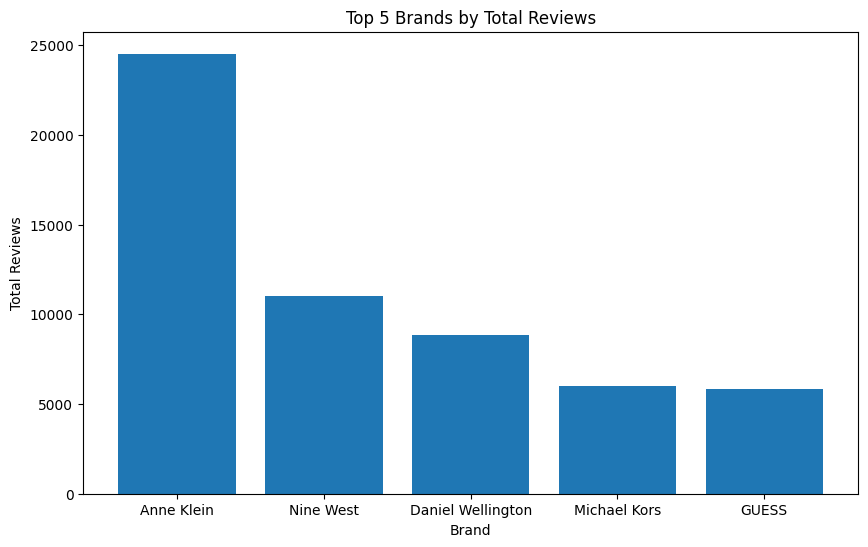

In [13]:
# ---------------------------------
# TOP 5 BRANDS BY TOTAL REVIEWS
# ---------------------------------

top5_brands = (
    df_clean
    .groupby("Brand")["No. of reviews"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))

plt.bar(
    top5_brands.index,
    top5_brands.values
)

plt.xlabel("Brand")
plt.ylabel("Total Reviews")
plt.title("Top 5 Brands by Total Reviews")

plt.show()


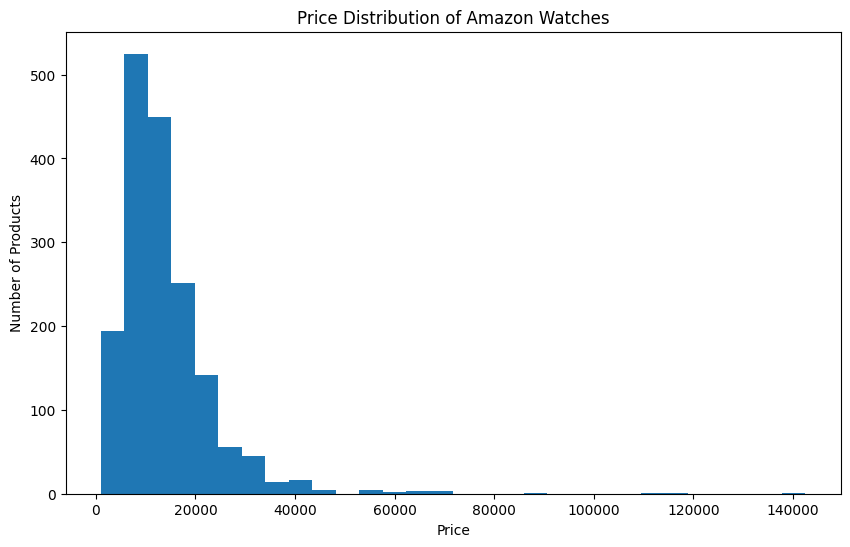

In [14]:
# ---------------------------------
# PRICE DISTRIBUTION
# ---------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    df_clean["Price"].dropna(),
    bins=30
)

plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.title("Price Distribution of Amazon Watches")

plt.show()

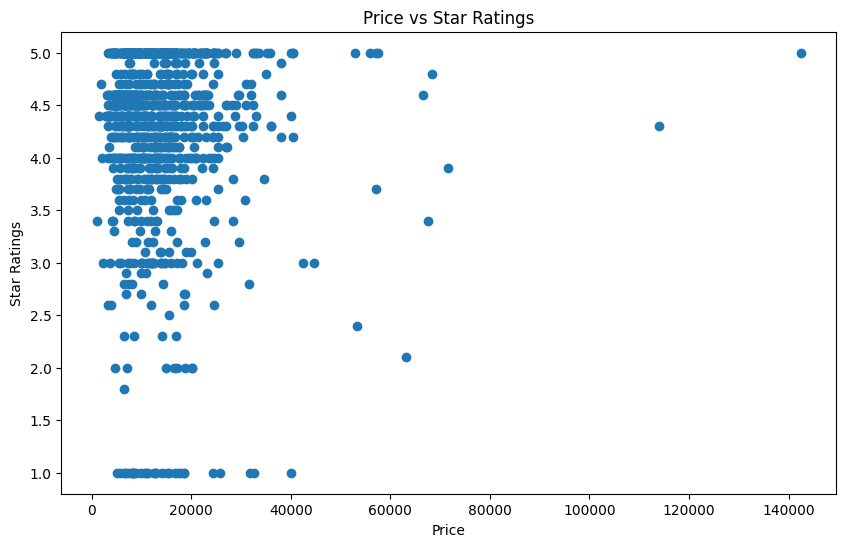

In [15]:
# ---------------------------------
# PRICE VS STAR RATINGS
# ---------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["Price"],
    df_clean["Star ratings"]
)

plt.xlabel("Price")
plt.ylabel("Star Ratings")
plt.title("Price vs Star Ratings")

plt.show()
